In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from github.Share import shared_iENG_sENG
from sklearn.manifold import TSNE

In [2]:
path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

subjects = {
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
        #indices = np.random.permutation(len(X)) # shuffle
        #X, y = X[indices], y[indices]

        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1

        if "subject2" in f:
            subjects["subject2"]["X"].append(X)
            subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            subjects["subject3"]["X"].append(X)
            subjects["subject3"]["Y"].append(y_int)

# T-SNE -> 저장해놔서 안돌려도됨

In [ ]:
bluetooth_id = 'E9AD0E7DCC2B'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG1, y_sENG1 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Hunmin/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG2, y_sENG2 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Byeongchan/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG3, y_sENG3 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Minjeong/{bluetooth_id}/raw/', num_session=[0], balance=True)
X_sENG, y_sENG = np.concatenate([X_sENG1, X_sENG2, X_sENG3], axis=0), np.concatenate([y_sENG1, y_sENG2, y_sENG3], axis=0)

X_iENG1, y_iENG1 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_iENG2, y_iENG2 = subjects["subject3"]["X"], subjects["subject3"]["Y"]
X_iENG1, y_iENG1 = shared_iENG_sENG.get_X_y(X_iENG1, y_iENG1, session=[0], balance=True)
X_iENG2, y_iENG2 = shared_iENG_sENG.get_X_y(X_iENG2, y_iENG2, session=[0], balance=True)
X_iENG, y_iENG = np.concatenate([X_iENG1, X_iENG2], axis=0), np.concatenate([y_iENG1, y_iENG2], axis=0)

###### iENG and sENG has different channels => 16 and 4; for iENG; randomly reduce it to 4.
#selected_channels = np.random.choice(X_iENG.shape[1], size=4, replace=False)
selected_channels = [1,5,6,9]
X_iENG = X_iENG[:, selected_channels, :, :]

X_iENG_flat = X_iENG.reshape(X_iENG.shape[0], -1)
X_sENG_flat = X_sENG.reshape(X_sENG.shape[0], -1)

X_combined = np.concatenate([X_iENG_flat, X_sENG_flat], axis=0)
y_combined = np.concatenate([y_iENG, y_sENG], axis=0)
labels_modality = np.array(['iENG'] * X_iENG.shape[0] + ['sENG'] * X_sENG.shape[0])

tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(15, 15), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid

#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [50]:
#pd.DataFrame(X_embedded).to_csv('./t-sne_sENG_iENG.csv', index=False)
#X_embedded = pd.read_csv('./t-sne_sENG_iENG.csv')

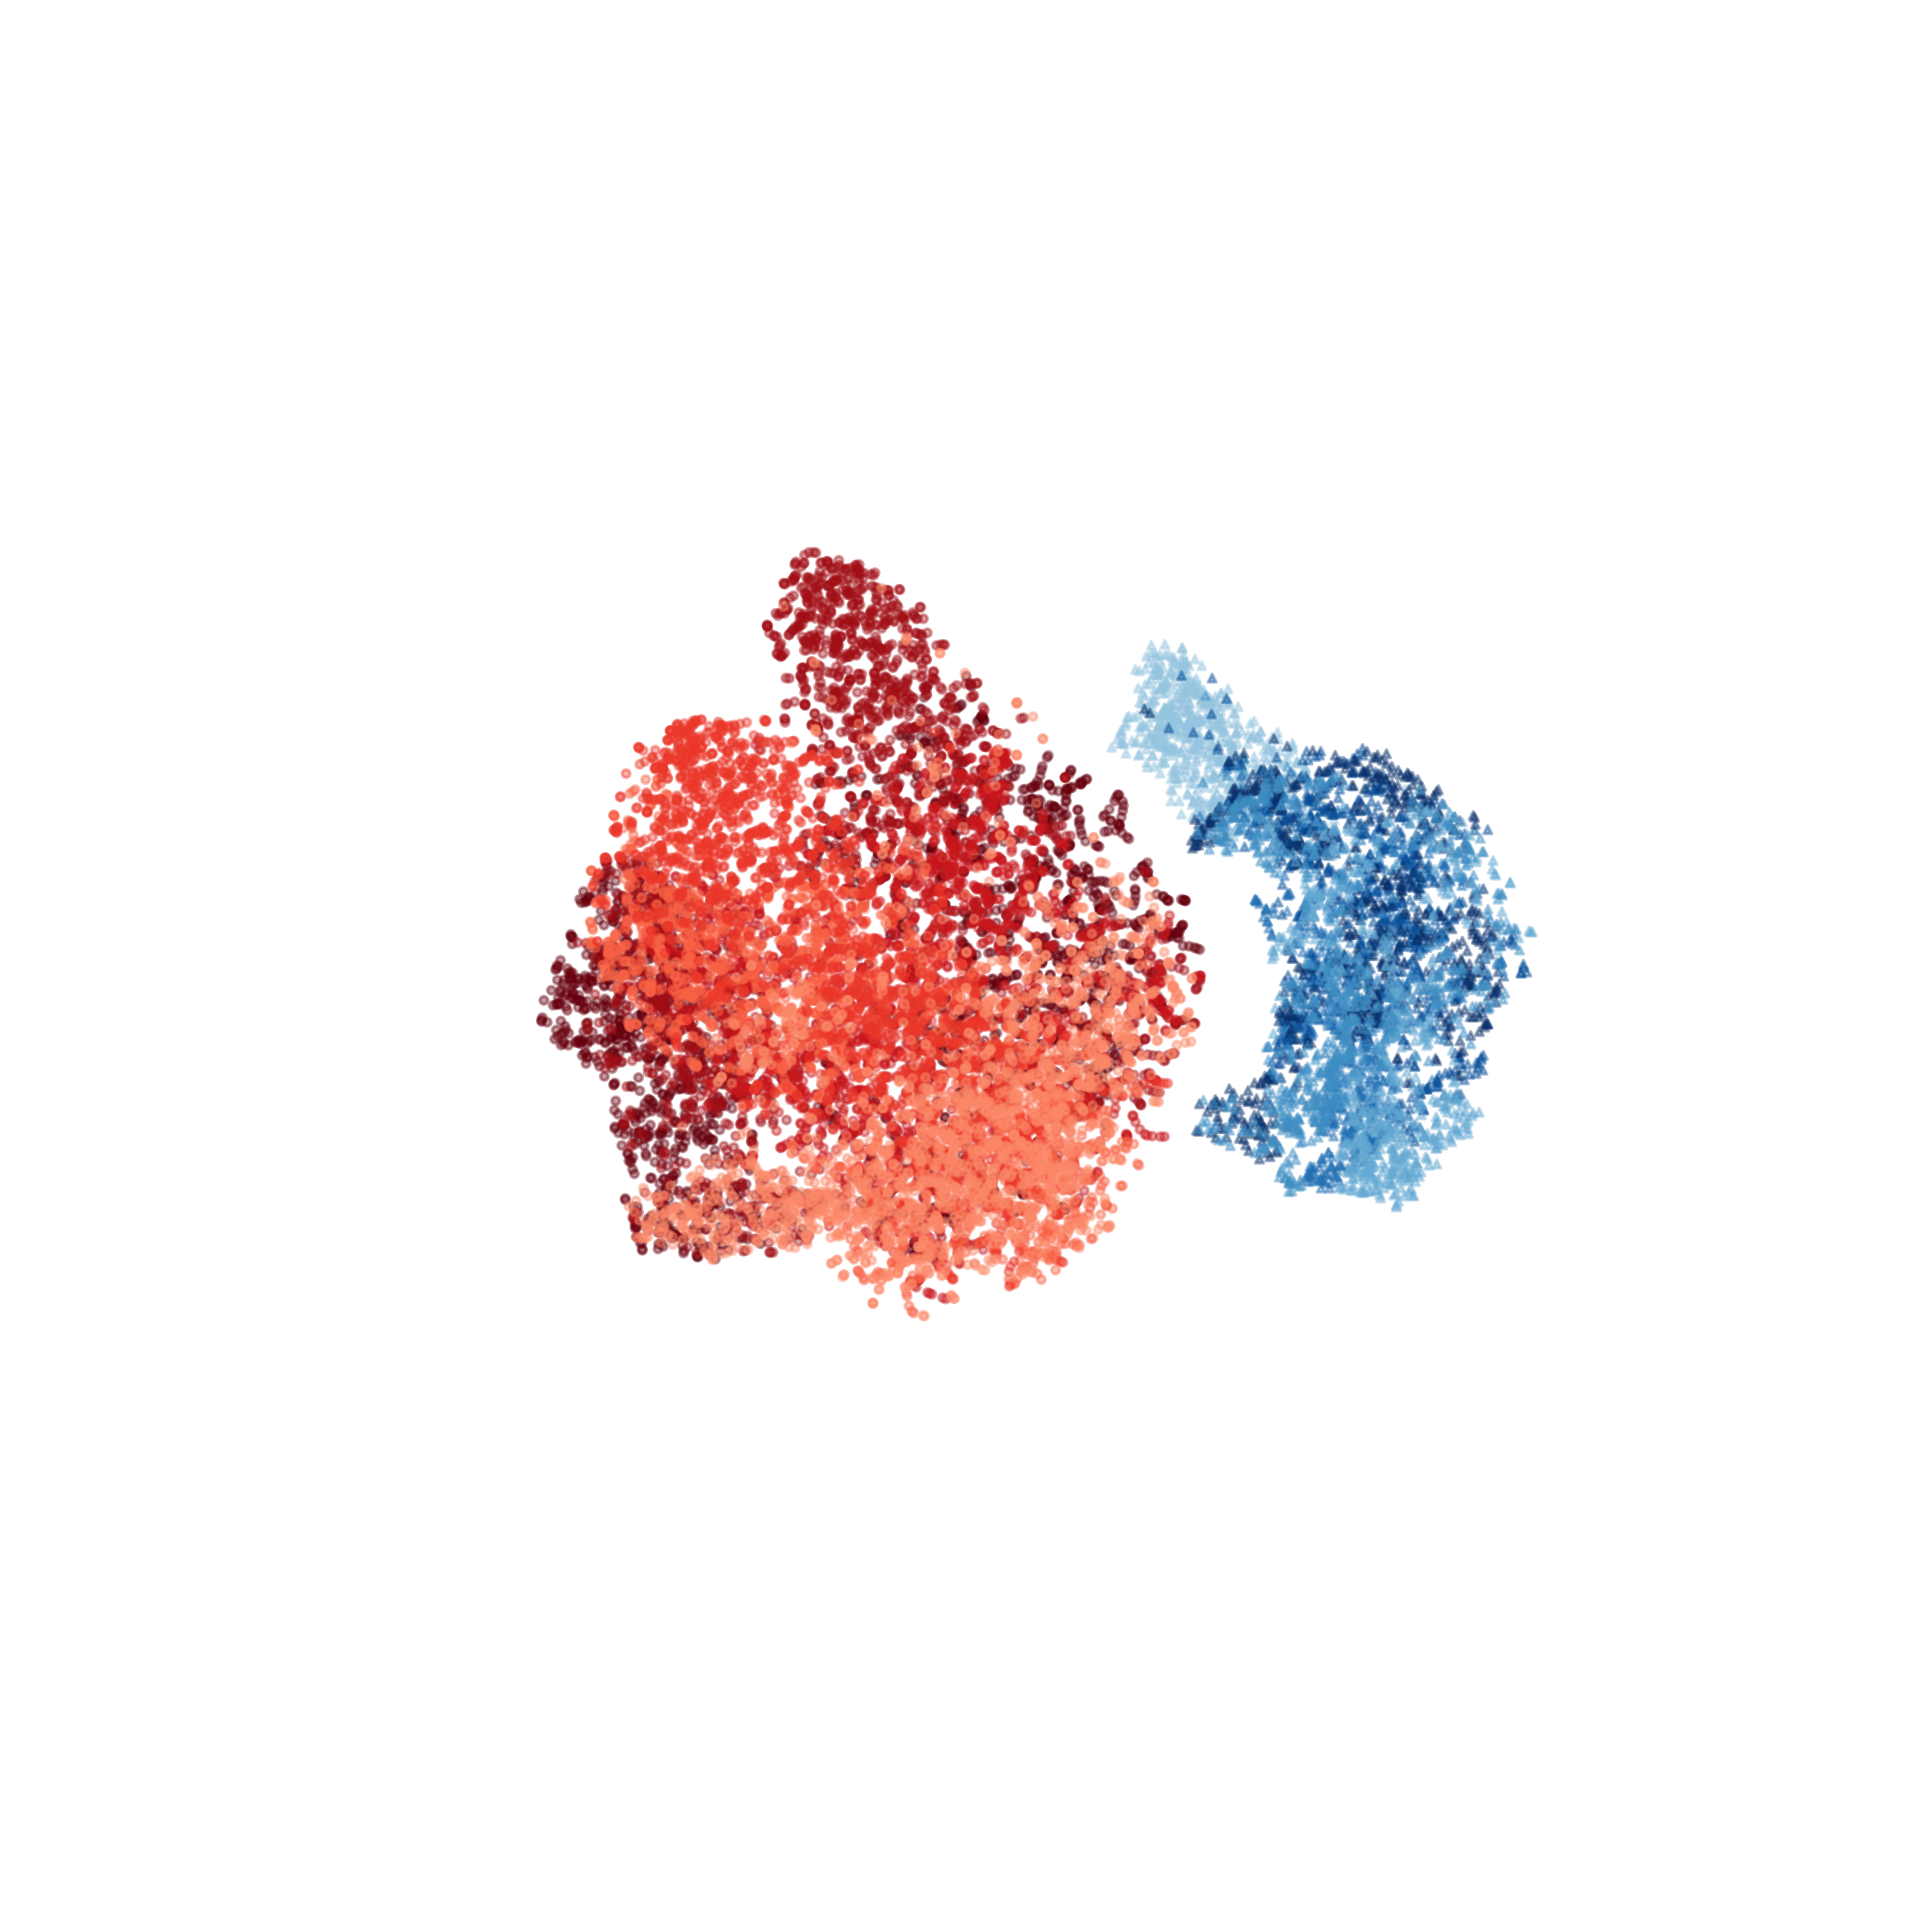

In [55]:
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=7, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.view_init(elev=30, azim=30)  # 예시
#ax.view_init(elev=10, azim=0)    # 정면에서 낮게 바라봄
#ax.view_init(elev=90, azim=0)    # 완전 위에서 내려다봄 (Top view)
#ax.view_init(elev=20, azim=120)  # 옆에서 비스듬히 봄
plt.tight_layout()
plt.show()

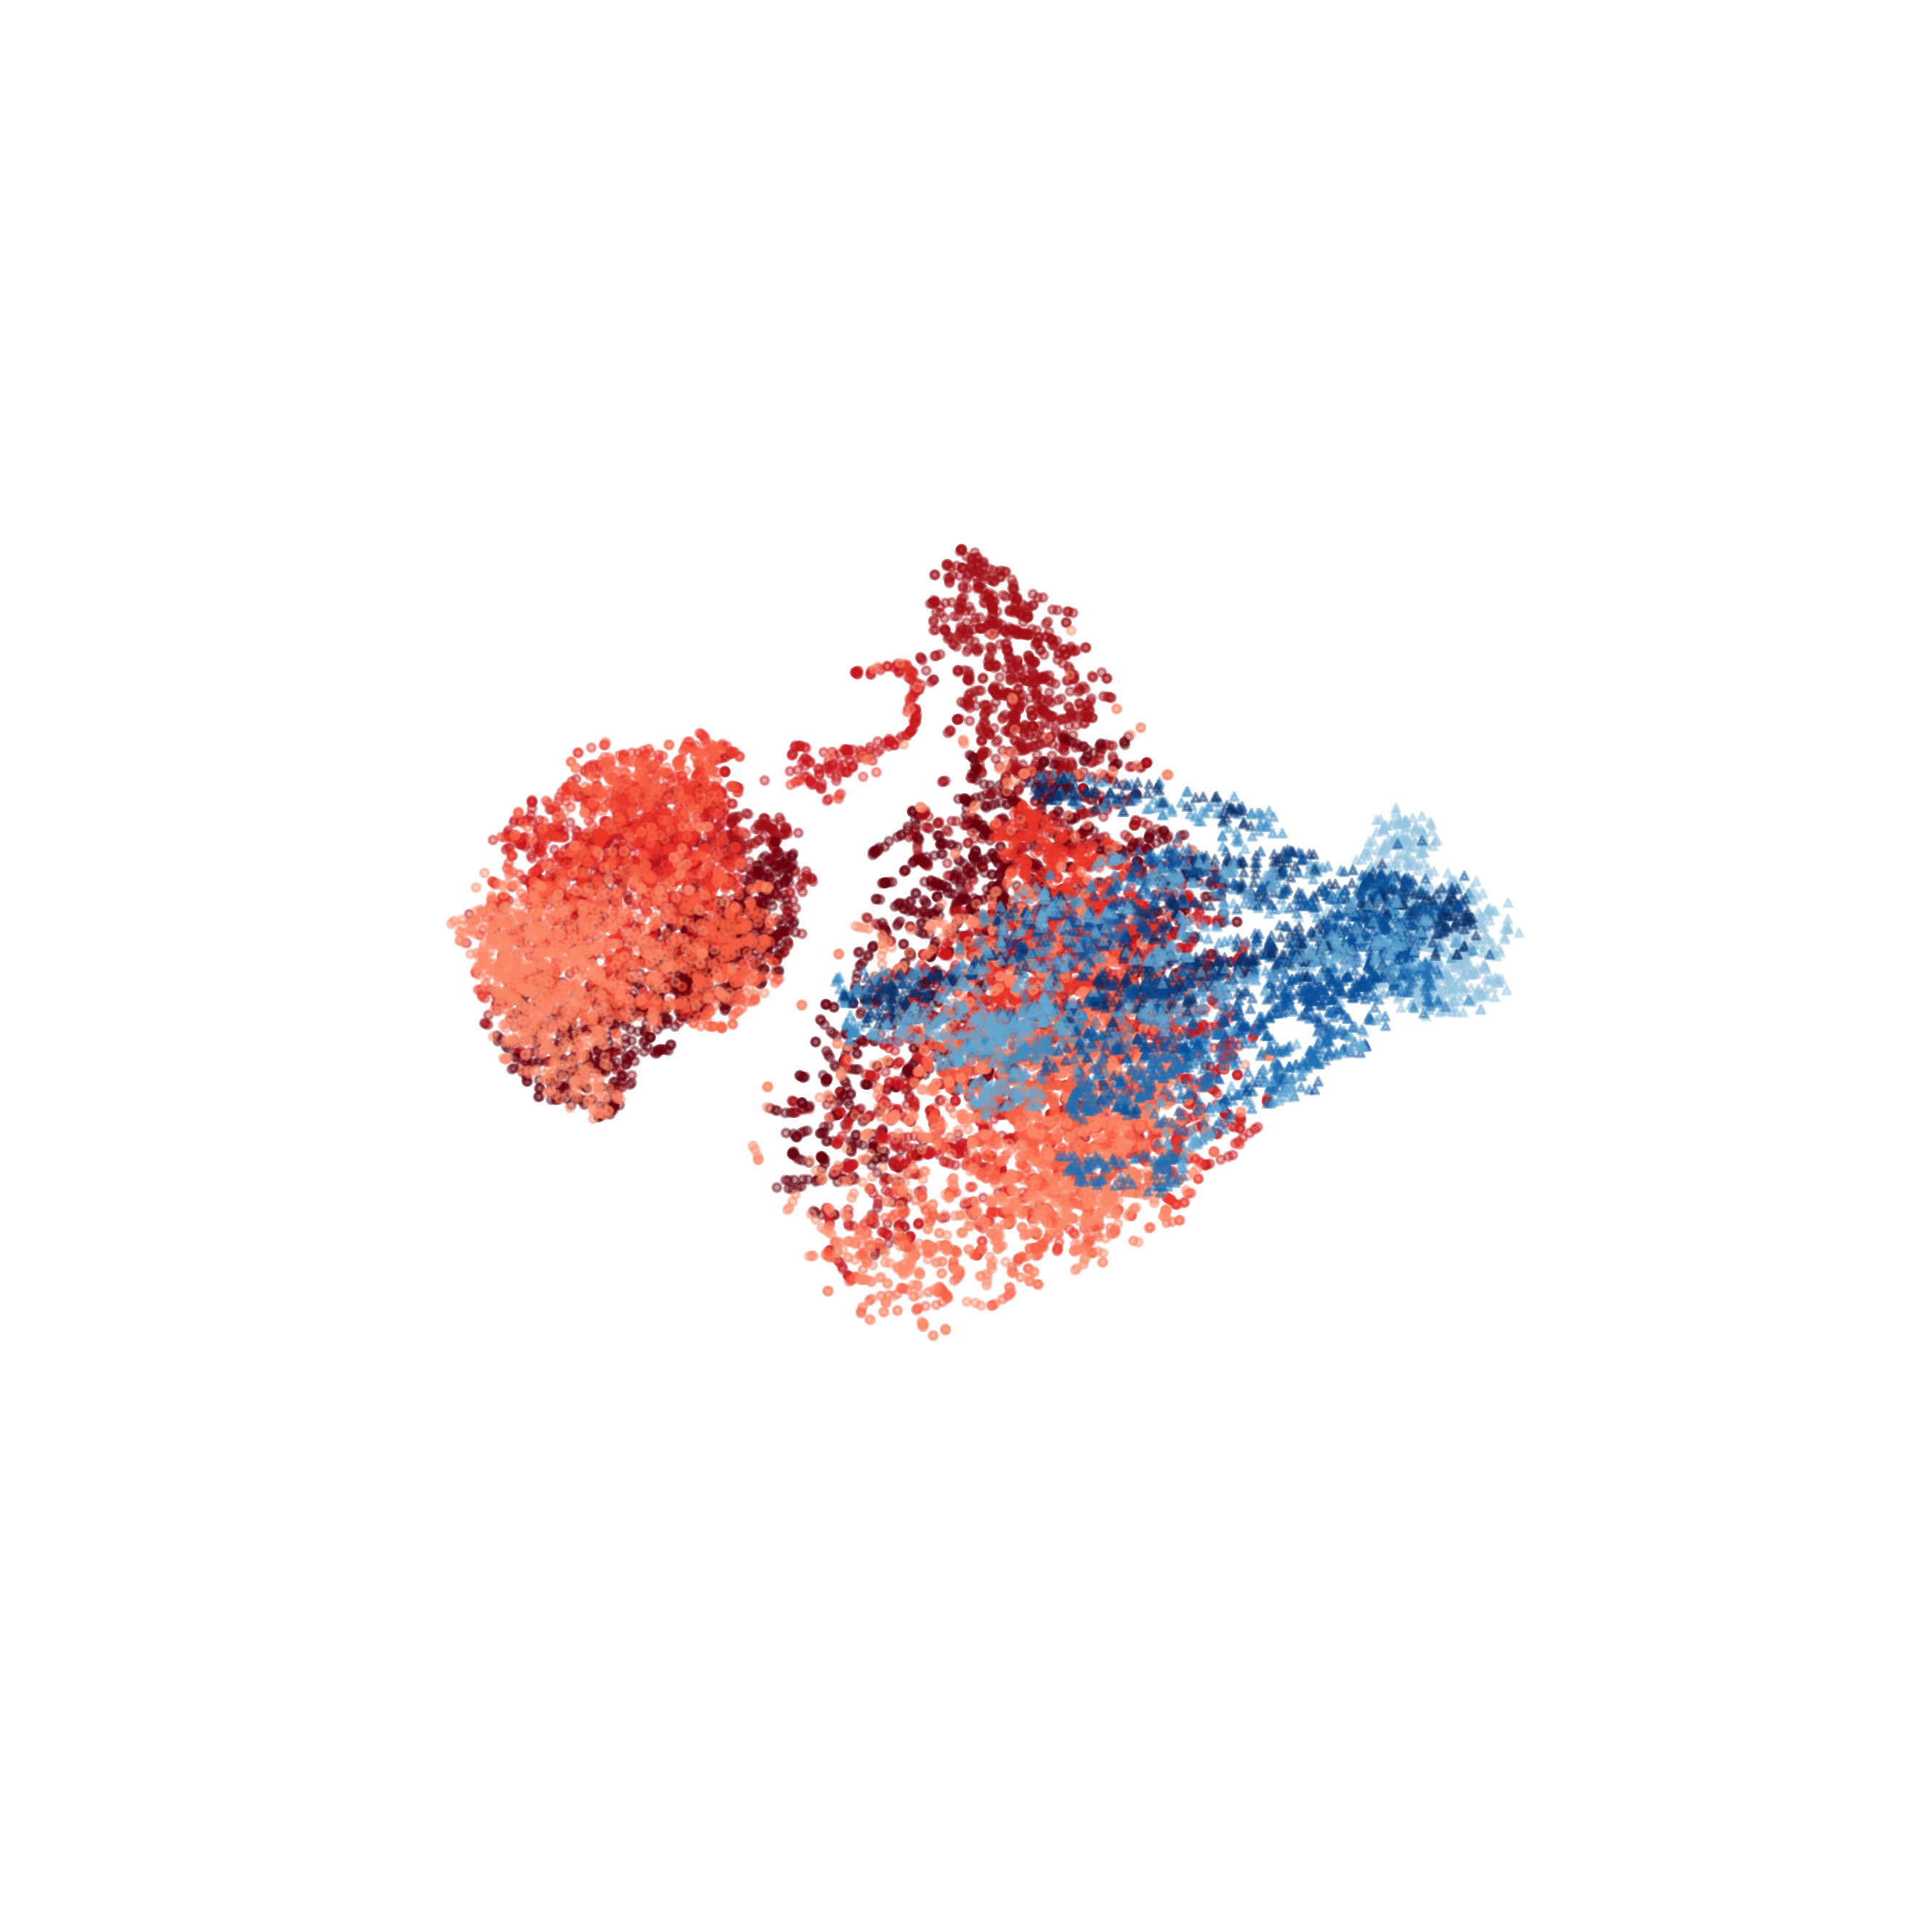

In [109]:
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=7, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
#ax.view_init(elev=30, azim=30)  # 예시
#ax.view_init(elev=10, azim=0)    # 정면에서 낮게 바라봄
#ax.view_init(elev=90, azim=0)    # 완전 위에서 내려다봄 (Top view)
ax.view_init(elev=0, azim=90)  # 옆에서 비스듬히 봄
plt.tight_layout()
plt.show()

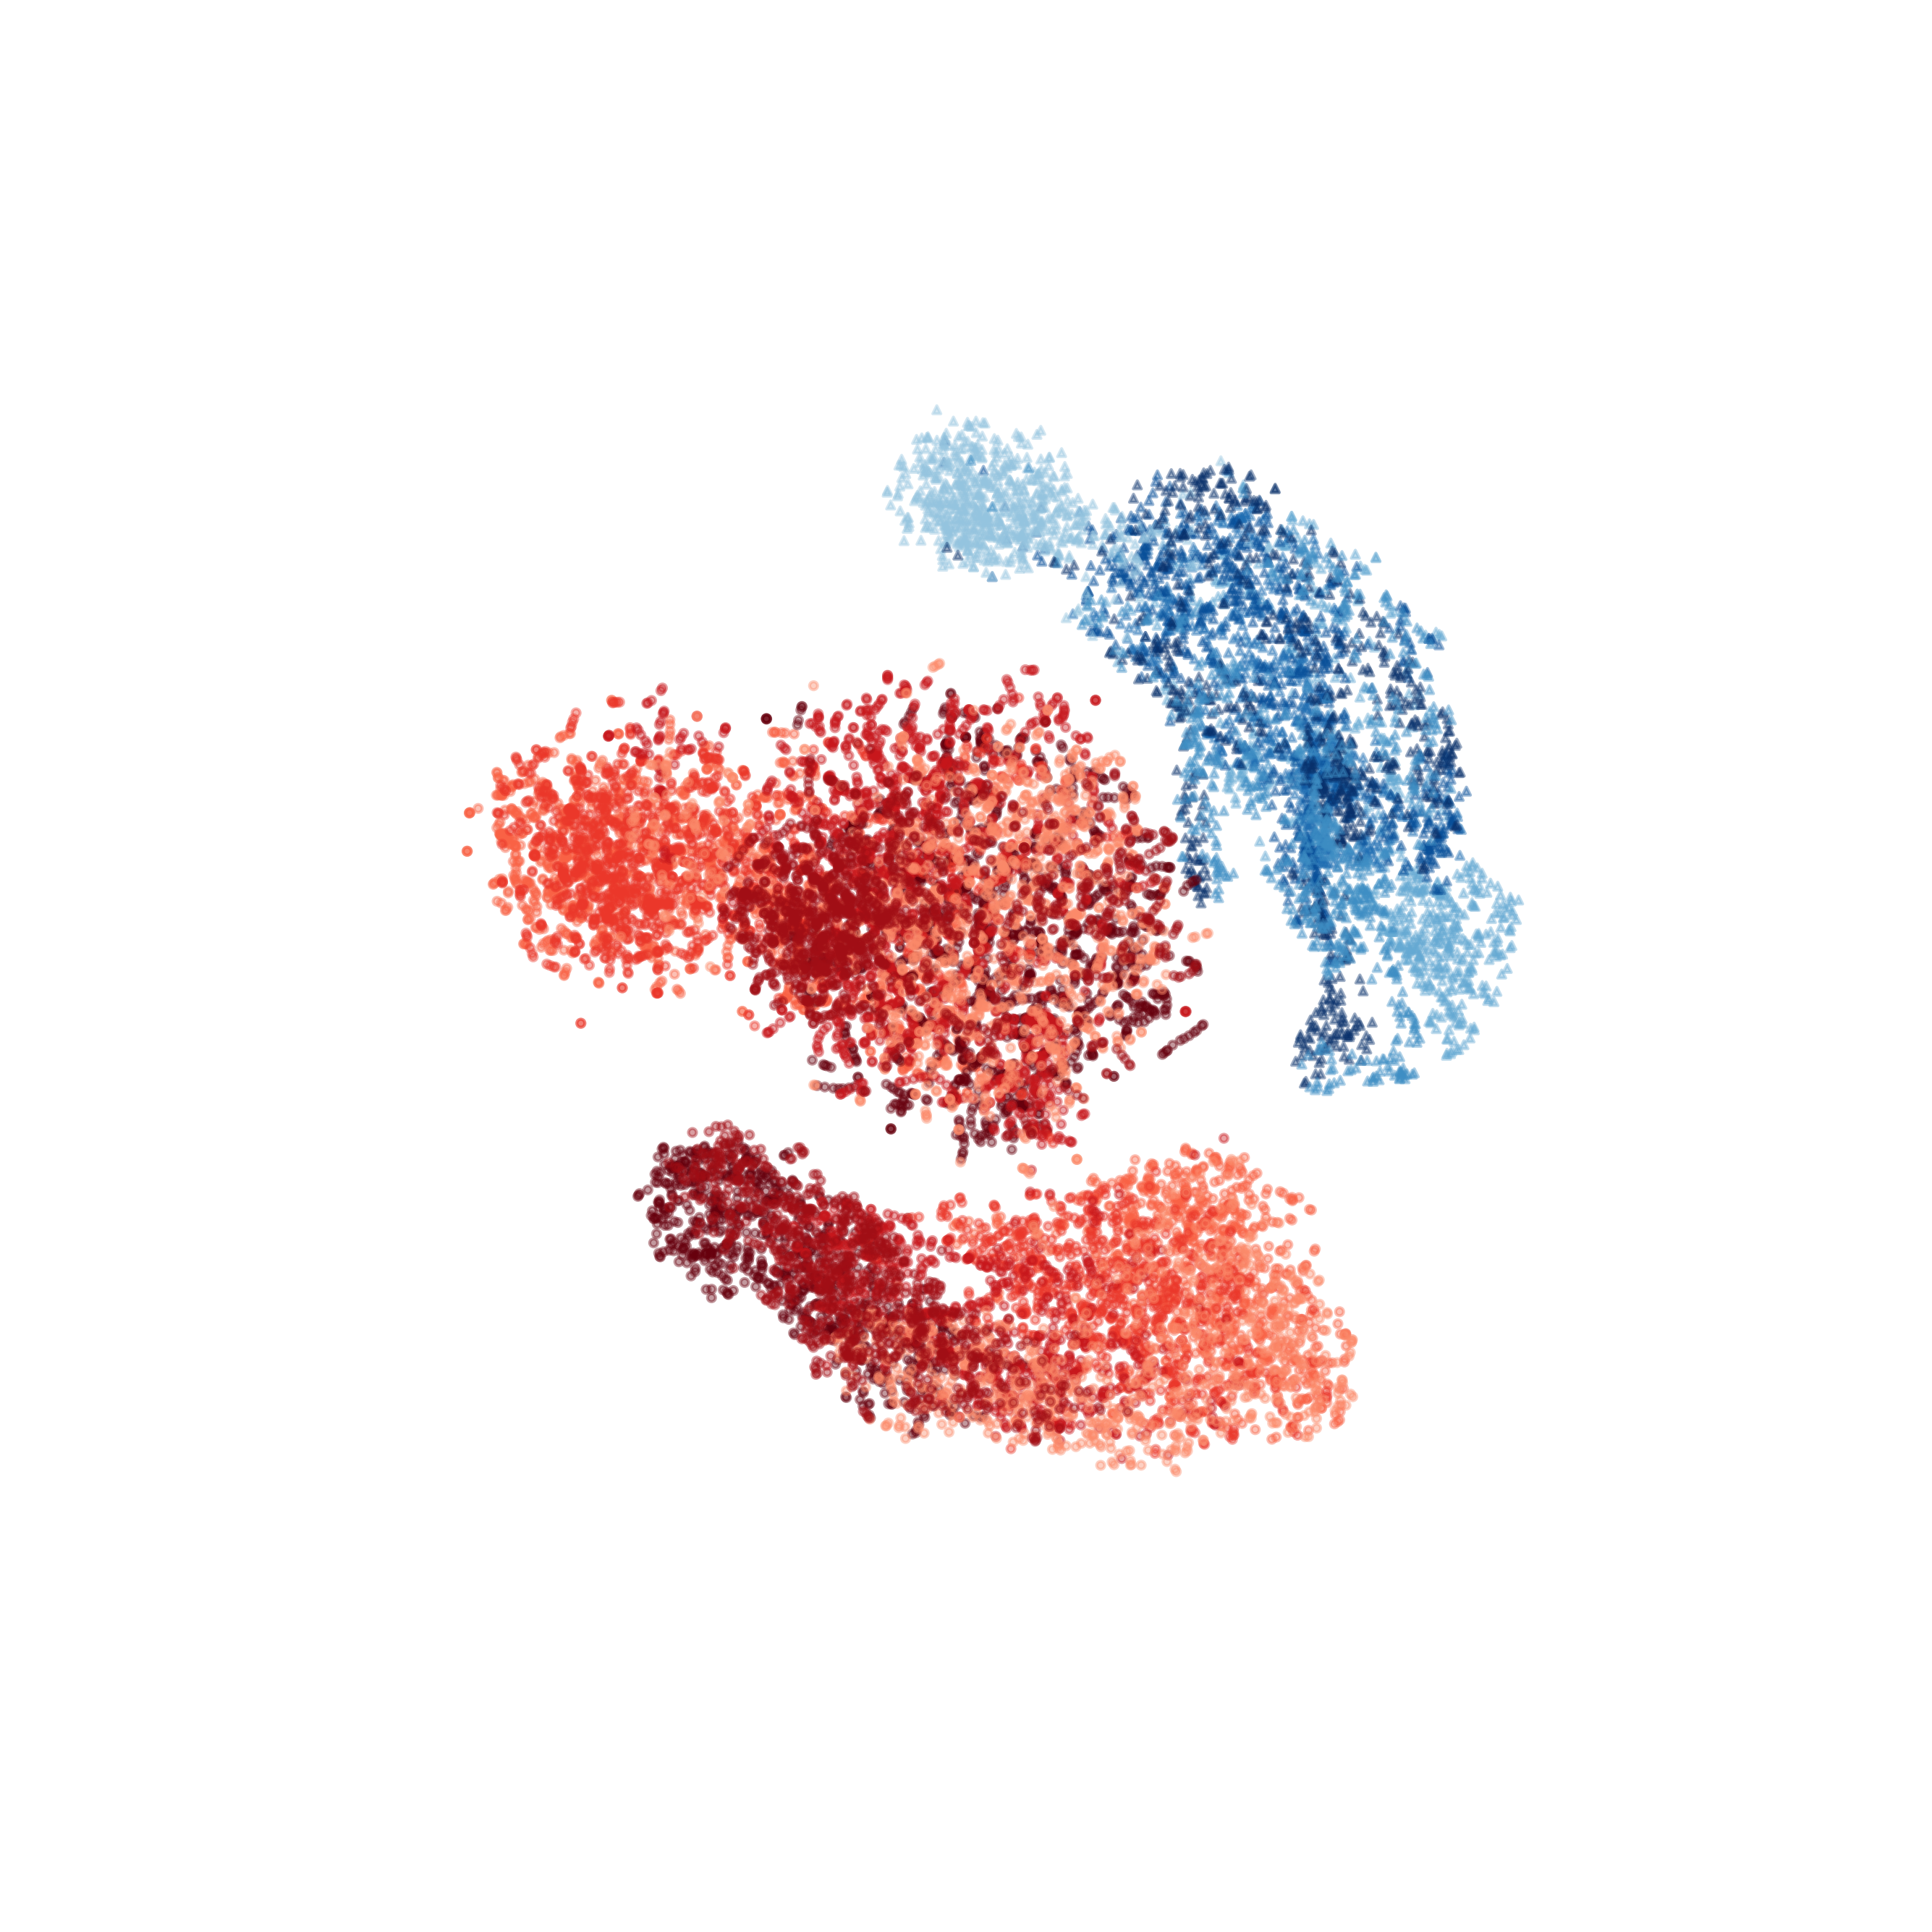

In [106]:
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 6))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 6)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(6):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=7, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
#ax.view_init(elev=30, azim=30)  # 예시
#ax.view_init(elev=10, azim=0)    # 정면에서 낮게 바라봄
ax.view_init(elev=90, azim=0)    # 완전 위에서 내려다봄 (Top view)
#ax.view_init(elev=20, azim=120)  # 옆에서 비스듬히 봄
plt.tight_layout()
plt.show()

# Heatmap - performance

In [ ]:
H = pd.read_csv('results/subject_H_cross_validation_result_sENG-6class.csv')
B = pd.read_csv('results/subject_BY_cross_validation_result_sENG-6class.csv')
M = pd.read_csv('results/subject_MJ_cross_validation_result_sENG-6class.csv')

amp1 = pd.read_csv('results/Amputee-iENG-S2-cross-val-6class.csv')
amp2 = pd.read_csv('results/Amputee-iENG-S3-cross-val-6class.csv')

In [ ]:
cms = [H, B, M]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = shared_iENG_sENG.heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

In [ ]:
cms = [amp1, amp2]  # list of confusion matrices
class_names = [f"Class {i}" for i in range(6)]
cm_mean, cm_std, mean_acc, std_acc = shared_iENG_sENG.heatmap_confusion_matrix_with_norm(cms, class_names, normalize=True)

# T-test heatmap

In [91]:
bluetooth_id = 'E9AD0E7DCC2B'
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
X_sENG1, y_sENG1 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Hunmin/{bluetooth_id}/raw/', num_session=[0, 1, 2, 3, 4], balance=True)
X_sENG2, y_sENG2 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Byeongchan/{bluetooth_id}/raw/', num_session=[0, 1, 2, 3, 4], balance=True)
X_sENG3, y_sENG3 = shared_iENG_sENG.return_X_y_get_from_matfile(path =base_path + f'Minjeong/{bluetooth_id}/raw/', num_session=[0, 1, 2, 3, 4], balance=True)
X_sENG, y_sENG = np.concatenate([X_sENG1, X_sENG2, X_sENG3], axis=0), np.concatenate([y_sENG1, y_sENG2, y_sENG3], axis=0)

X_iENG1, y_iENG1 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
X_iENG2, y_iENG2 = subjects["subject3"]["X"], subjects["subject3"]["Y"]
X_iENG1, y_iENG1 = shared_iENG_sENG.get_X_y(X_iENG1, y_iENG1, session=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], balance=True)
X_iENG2, y_iENG2 = shared_iENG_sENG.get_X_y(X_iENG2, y_iENG2, session=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], balance=True)
X_iENG, y_iENG = np.concatenate([X_iENG1, X_iENG2], axis=0), np.concatenate([y_iENG1, y_iENG2], axis=0)
#(129462, 16, 14, 1) (21330, 4, 14, 1)
print(X_iENG.shape, X_sENG.shape)

(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(143832, 16, 14, 1) (21330, 4, 14, 1)


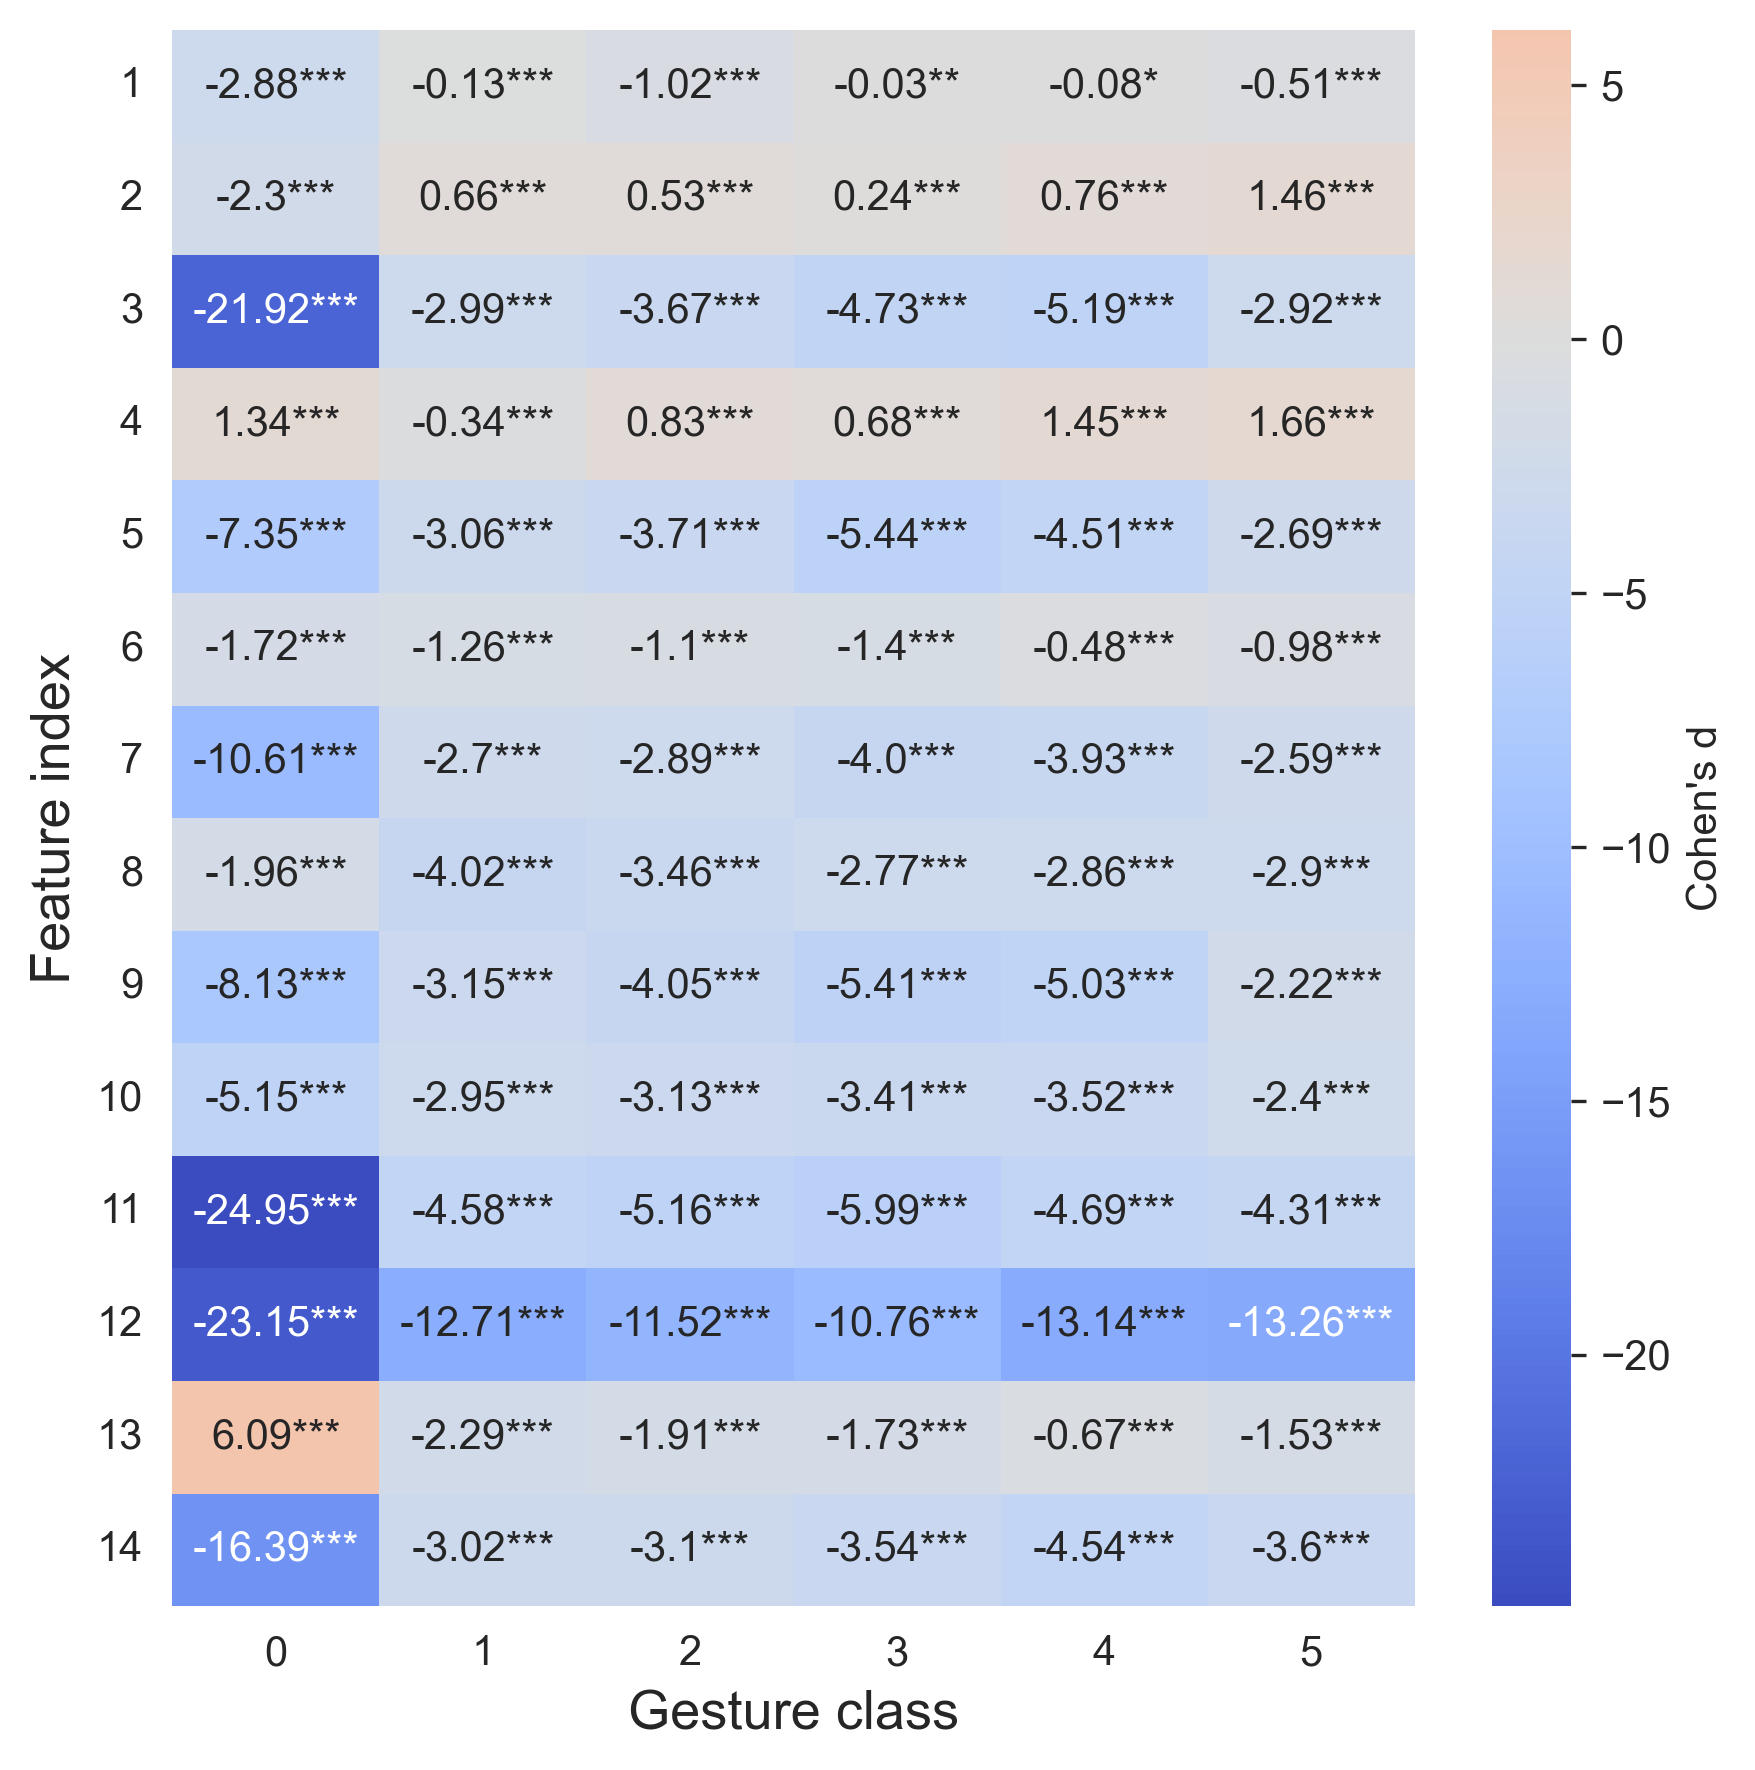

In [102]:
from scipy.stats import ttest_ind

# RMS 계산
def rms(x):
    return np.sqrt(np.mean(x**2, axis=0))  # x.shape = (channels, features)

# ---------------------------
gestures = [0,1,2,3,4,5]#["G0", "G1", "G2", "G3", "G4", "G5"]
#features = ['Zero Crossing', 'Slope Sign Changes', 'Waveform Length', 'Willison Amplitude', 'Mean Absolute Value', 'Mean Square', 'Root Mean Square', 'V-order 3', 'Log detector', 'Difference absolute standard deviation value', 'Maximum fractal length', 'Myopulse percentage rate', 'Mean absolute value slope', 'Weighted mean absolute']

features = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
# ---------------------------
# Gesture × Feature 비교
# ---------------------------
p_values = np.zeros((len(features), len(gestures)))
effect_sizes = np.zeros((len(features), len(gestures)))

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

for j, gest in enumerate(gestures):
    # gesture별 샘플 선택
    idx_i = np.where(y_iENG == gest)[0]
    idx_s = np.where(y_sENG == gest)[0]

    X_i_class = X_iENG[idx_i]  # shape = (samples_i_class, channels, features)
    X_s_class = X_sENG[idx_s]  # shape = (samples_s_class, channels, features)

    # RMS로 채널 요약
    iENG_summary = np.array([rms(x) for x in X_i_class])
    sENG_summary = np.array([rms(x) for x in X_s_class])

    for f in range(len(features)):
        x = iENG_summary[:, f]
        y = sENG_summary[:, f]

        # Welch's t-test
        t_stat, p_val = ttest_ind(x, y, equal_var=False)
        p_values[f, j] = p_val
        effect_sizes[f, j] = cohens_d(x, y)


df_effect = pd.DataFrame(effect_sizes, index=features, columns=gestures)
df_pval = pd.DataFrame(p_values, index=features, columns=gestures)

# Significance stars
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

annot = df_effect.round(2).astype(str)
for i in range(df_effect.shape[0]):
    for j in range(df_effect.shape[1]):
        annot.iloc[i, j] += significance_stars(df_pval.iloc[i, j])

# ---------------------------
# Heatmap 시각화
# ---------------------------
plt.figure(figsize=(6, 6), dpi=300)
sns.heatmap(df_effect, annot=annot, fmt='', cmap='coolwarm', center=0,
            cbar_kws={'label': "Cohen's d"})
#plt.title("iENG vs sENG Comparison per Gesture")
plt.xlabel("Gesture class", fontsize=13)
plt.ylabel("Feature index", fontsize=13)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

둘을 같이 보면
- 큰 d + 작은 p → 의미 있는 큰 차이
- 작은 d + 작은 p → 표본 많아서 유의하지만 차이는 작음
- 큰 d + 큰 p → 차이가 크지만 표본 적어서 통계적으로 유의하지 않음

쉽게 그림으로 표현하면:

d값: Cohen's d (절댓값)	차이 크기
- 0 ~ 0.2	아주 작은 차이 / 무시 가능
- 0.2 ~ 0.5	작은 차이
- 0.5 ~ 0.8	중간 정도 차이
- 0.8 이상	큰 차이

d값 | p-value | 해석 <br>
큰  	| 작은     | 실제로 중요한 차이 (best) <br>
작은  	| 작은     | 차이는 작지만 통계적으로 검출 가능 <br>
큰	    | 큰       | 차이는 크지만 표본이 적어서 신뢰 낮음 <br>
작은  	| 큰       | 의미 없는 차이